import needed libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy

read in one of the DepMap datasets (PRISM)

In [2]:
screenData = pd.read_csv('Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv')
drugMetadata = pd.read_csv('Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv')

take a smaller slice of the data for testing purposes (transpose for correlation steps later)


In [3]:
screenDataSlice = screenData.iloc[0:1000, 0:300]
screenDataSlice = screenDataSlice.set_index('Unnamed: 0')
screenDataSlice = screenDataSlice.T

plot an exploratory heatmap 

<Axes: xlabel='Unnamed: 0'>

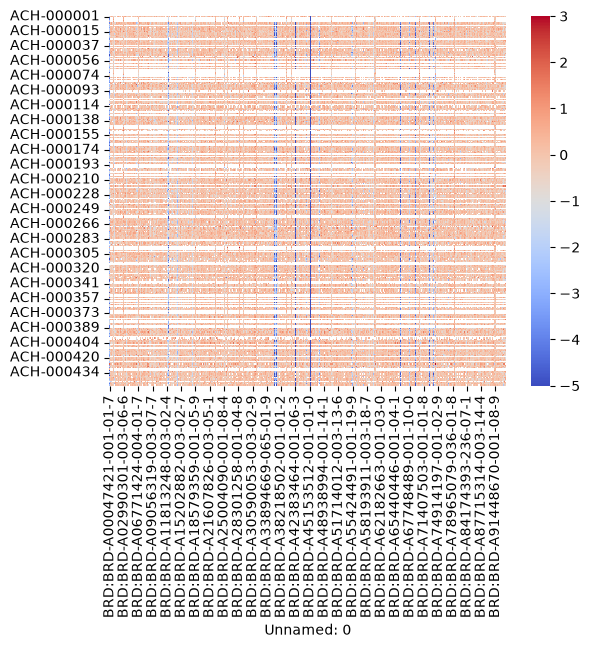

In [5]:
sea.heatmap(screenDataSlice, annot=False, vmin=-5, vmax=3, cmap='coolwarm')

Here, 'ACH' identifiers are cell lines, and 'BRD' identifiers are drugs. So, most of these cells lines have been treated with most of the drugs, but a subset of cell lines have only been treated with a subset of drugs (not really a problem for drug-drug correlations, I think). You can also sort of tell that many drug effects are near zero (i.e. no effect of that drug on that cell line), which makes sense. A few drugs have very strong effects in the majority of cell lines. 

Let's make a drug-drug correlation matrix of this data and plot with a heatmap (defaults to Pearson correlations). 

<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

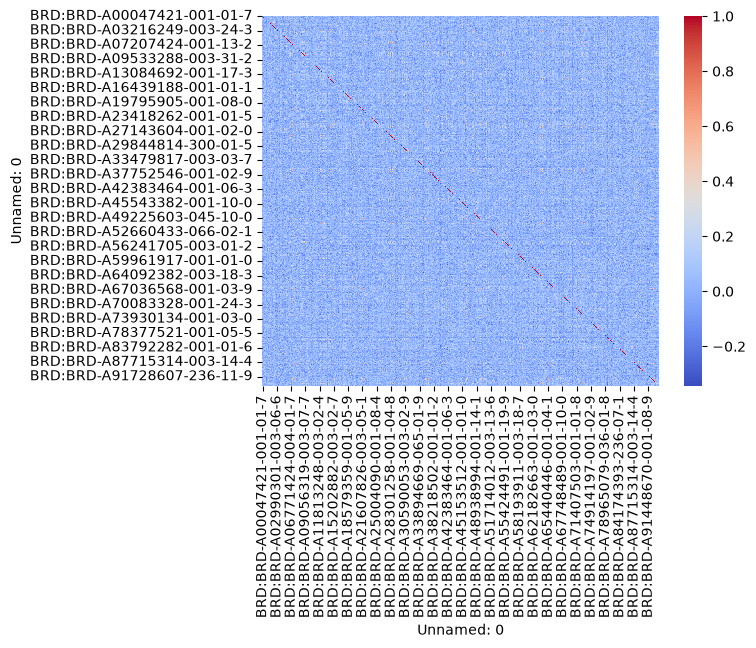

In [8]:
corr_matrix = screenDataSlice.corr(numeric_only=True)
sea.heatmap(corr_matrix, annot=False, cmap='coolwarm')

It's difficult to see, but this indicates that the majority of drugs pairs do not show strong correlation- another good sign. We will examine this in more detail in a bit. 

Let's repeat the correlation analysis for the full dataset this time:

In [9]:
screenData = screenData.set_index('Unnamed: 0')
screenData = screenData.T

corr_matrix_full = screenData.corr(numeric_only=True)

Instead of plotting the correlation matrix as a heatmap, let's look at the distribution of correlations: 

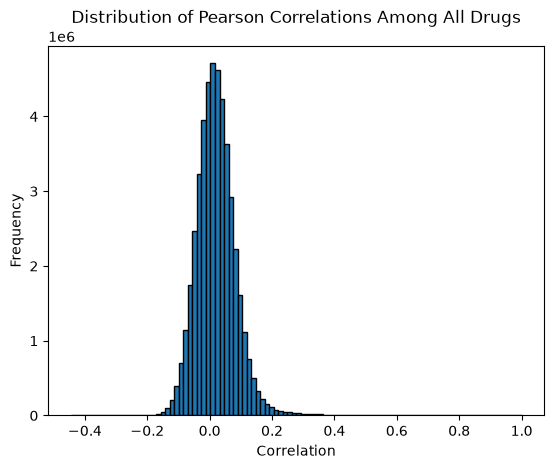

In [11]:
plt.hist(corr_matrix_full.values.flatten(), bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('linear')

It's cool to see that the distribution looks pretty Gaussian, and is pretty much centered around 0 (that is, most drug pairs show no strong correlation, as we'd expect). However, if my method is to work, there need to be *some* drug pairs that do correlate, so I suspect that this distribution has a tail. Plot on a log scale to see if this is true: 

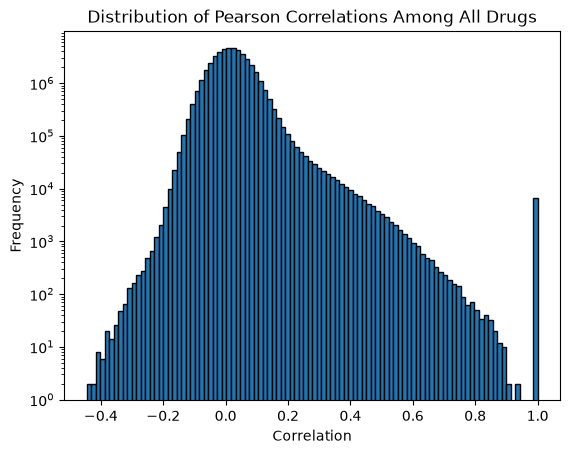

In [12]:
plt.hist(corr_matrix_full.values.flatten(), bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('log')

Indeed, there are some drug pairs that show a range of 'stronger' correlation values. I'm a little confused why there are ~10^4 drug pairs with perfect correlation (when there should be 6790, the number of drugs in the correlation matrix), but maybe this is a trick of the axes... this also shows that there isn't really a natural 'shoulder' or cutoff value to use as a threshold for 'meaningful' correlation. 

To facilitate isolating drug pairs with specific correlations, let's reshape the correlation matrix: 

In [21]:
corr_matrix_tofilter = corr_matrix_full
corr_matrix_tofilter['Drug'] = corr_matrix_tofilter.index
col_to_move = corr_matrix_tofilter.pop('Drug')
corr_matrix_tofilter.insert(0, 'Drug', col_to_move)
corr_matrix_tofilter_long = pd.melt(corr_matrix_tofilter, id_vars ='Drug', var_name='Partner', value_name='Pearson')

Plot histogram of 'Pearson' column as a sanity check: 

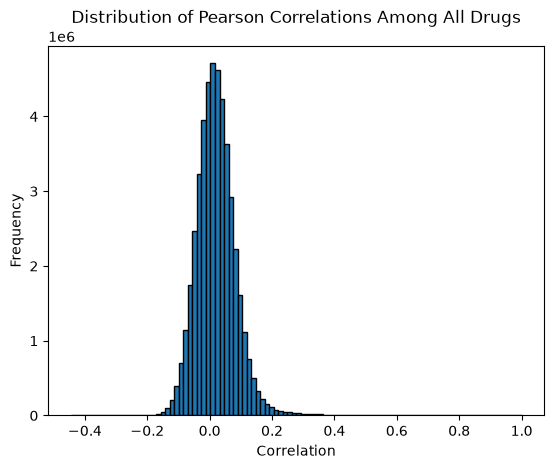

In [22]:
plt.hist(corr_matrix_tofilter_long['Pearson'], bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('linear')

Sort this new correlation dataframe by correlationt to find the top correlating drug pairs (and filter out the pairs with perfect correlation): 

In [ ]:
corr_matrix_tofilter_descending = corr_matrix_tofilter_long.sort_values(by='Pearson', ascending=False)
corr_matrix_tofilter_descending = corr_matrix_tofilter_descending[corr_matrix_tofilter_long['Pearson'] != 1.0]

<positron-console-cell-26>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


In [29]:
corr_matrix_tofilter_descending.head(10)

,Drug,Partner,Pearson
1290954,BRD:BRD-A78210457-001-01-5,BRD:BRD-A16035238-001-01-7,0.929351
5798850,BRD:BRD-A16035238-001-01-7,BRD:BRD-A78210457-001-01-5,0.929351
36114141,BRD:BRD-K61397605-001-03-4,BRD:BRD-K69650333-003-14-0,0.907663
33418908,BRD:BRD-K69650333-003-14-0,BRD:BRD-K61397605-001-03-4,0.907663
9221010,BRD:BRD-A16035238-001-01-7,BRD:BRD-K00003406-001-01-9,0.898368
1291458,BRD:BRD-K00003406-001-01-9,BRD:BRD-A16035238-001-01-7,0.898368
30261161,BRD:BRD-K61397605-001-03-4,BRD:BRD-K51911221-001-01-2,0.893951
33418046,BRD:BRD-K51911221-001-01-2,BRD:BRD-K61397605-001-03-4,0.893951
21820344,BRD:BRD-K44432556-001-05-5,BRD:BRD-K26122255-001-01-7,0.892588
27665673,BRD:BRD-K26122255-001-01-7,BRD:BRD-K44432556-001-05-5,0.892588


This is cool- also reveals that all of the correlations are duplicated (drug A corr with drug B vs drug B corr with drug A) which is a small issue to fix later. Let's plot the top correlated drug pair and find the drug identities using the drug screen metadata dataframe: 

In [ ]:
drug_A = corr_matrix_tofilter_descending.iat[0,0]
drug_B = corr_matrix_tofilter_descending.iat[0,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

<Axes: xlabel='BRD:BRD-A78210457-001-01-5', ylabel='BRD:BRD-A16035238-001-01-7'>

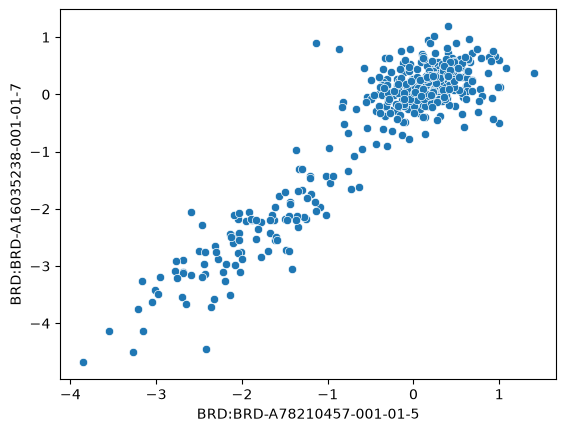

In [35]:
sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

This is really cool in that is shows a cluster of cell lines around (0,0), indicating that these cells don't really care about either drug. But, cell lines which care about one drug (i.e. have a non-zero effect of that drug) also tend to care about the other drug to a similar extent. 

In [40]:
drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
4705,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A16035238-001-01-7,SAR405838,SAR405838
4754,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A78210457-001-01-5,RG7112,RG7112


What do you know, these are two different drugs with the same target (MDM2), as we would predict! Let's try the same thing for a few other drug pairs:

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
2908,REP.PRIMARY,2.5,"MDM2, TP53",MDM INHIBITOR,BRD:BRD-K62627508-001-01-5,IDASANUTLIN,IDASANUTLIN
4705,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A16035238-001-01-7,SAR405838,SAR405838


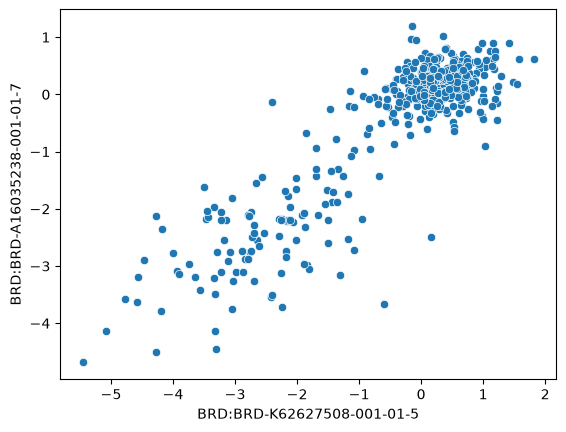

In [42]:
drug_A = corr_matrix_tofilter_descending.iat[10,0]
drug_B = corr_matrix_tofilter_descending.iat[10,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
1208,REP.PRIMARY,2.5,"MAP2K1, MAP2K2",MEK INHIBITOR,BRD:BRD-K12343256-001-08-9,TRAMETINIB,TRAMETINIB
3781,REP.PRIMARY,2.5,"MAP2K1, MAP2K2",MEK INHIBITOR,BRD:BRD-K89014967-001-04-3,AS-703026,AS-703026


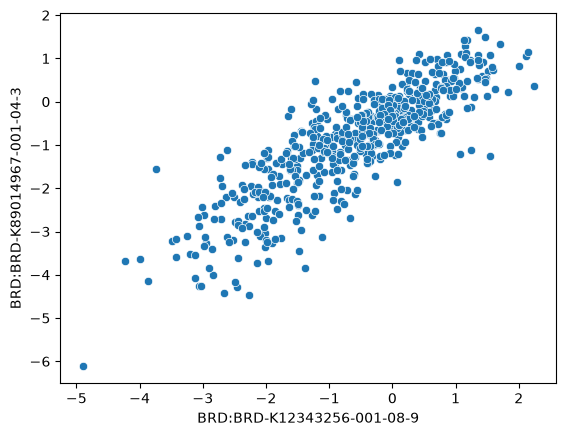

In [43]:
drug_A = corr_matrix_tofilter_descending.iat[50,0]
drug_B = corr_matrix_tofilter_descending.iat[50,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
5204,REP.PRIMARY,2.5,"BRAF, MAP2K1, MAP2K2, RAF1","MEK INHIBITOR, RAF INHIBITOR",BRD:BRD-K82804538-001-01-0,RO-5126766,RO-5126766
5259,REP.PRIMARY,2.5,MAPK1,MAP KINASE INHIBITOR,BRD:BRD-K93725829-001-03-8,VX-11E,VX-11E


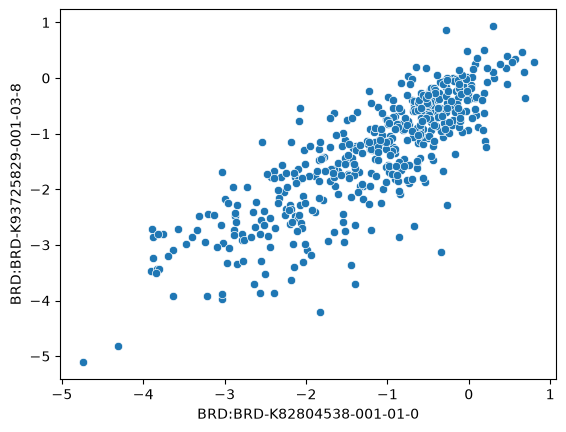

In [44]:
drug_A = corr_matrix_tofilter_descending.iat[100,0]
drug_B = corr_matrix_tofilter_descending.iat[100,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
5351,REP.1M,2.5,NaN,BROMODOMAIN INHIBITOR,BRD:BRD-K00003108-001-01-9,ABBV-744,ABBV-744
5992,REP.1M,2.5,NaN,BROMODOMAIN INHIBITOR,BRD:BRD-K00005242-001-01-9,TEN-010,TEN-010


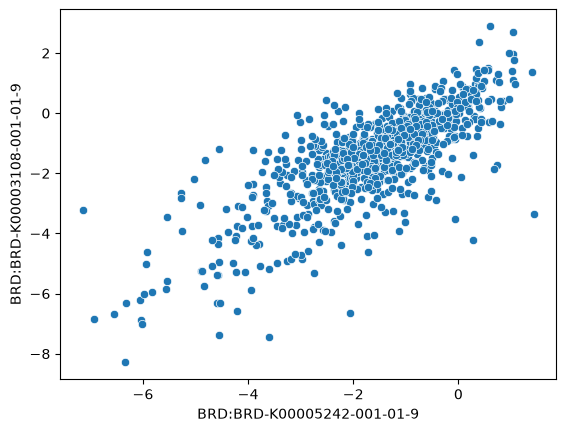

In [45]:
drug_A = corr_matrix_tofilter_descending.iat[300,0]
drug_B = corr_matrix_tofilter_descending.iat[300,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
6704,REP.300,2.5,NaN,NaN,BRD:BRD-K00091075-001-01-9,E-7386,E-7386
6729,REP.300,2.5,NaN,NaN,BRD:BRD-K00091108-001-01-9,PRI-724,PRI-724


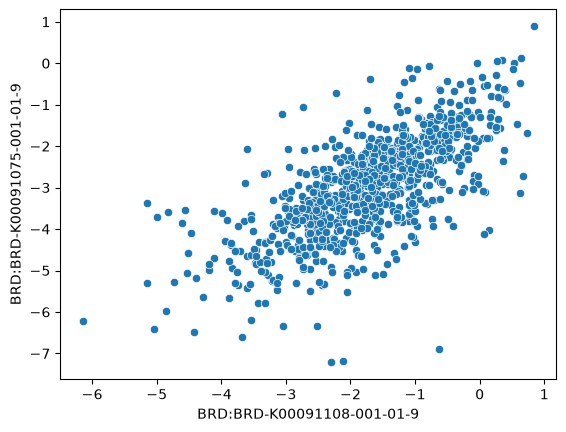

In [46]:
drug_A = corr_matrix_tofilter_descending.iat[1000,0]
drug_B = corr_matrix_tofilter_descending.iat[1000,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

This drug pair have no annotated targets in this metadata, but a quick Google search reveals them both to be inhibitors of the Wnt/Beta-catenin pathway. This is a good example of the drug metadata being useful but not complete (just because a drug doesn't have an annotated target here doesn't mean that its target is unknown...)

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
3956,REP.PRIMARY,2.5,CTNNB1,BETA-CATENIN INHIBITOR,BRD:BRD-K94455792-001-01-8,ICG-001,ICG-001
6729,REP.300,2.5,NaN,NaN,BRD:BRD-K00091108-001-01-9,PRI-724,PRI-724


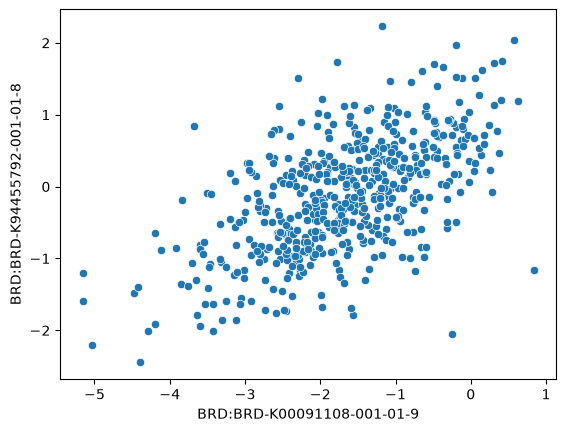

In [47]:
drug_A = corr_matrix_tofilter_descending.iat[5000,0]
drug_B = corr_matrix_tofilter_descending.iat[5000,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

           screen  dose repurposing_target                       MOA                         IDs    Drug.Name     Synonyms
1221  REP.PRIMARY   2.5                NaN  RNA POLYMERASE INHIBITOR  BRD:BRD-K12787259-001-04-3      CX-5461      CX-5461
3460  REP.PRIMARY   2.5                NaN             DNA INHIBITOR  BRD:BRD-K78960041-001-03-2  OXALIPLATIN  OXALIPLATIN
                                Drug                     Partner   Pearson
17388188  BRD:BRD-K78960041-001-03-2  BRD:BRD-K12787259-001-04-3  0.415408


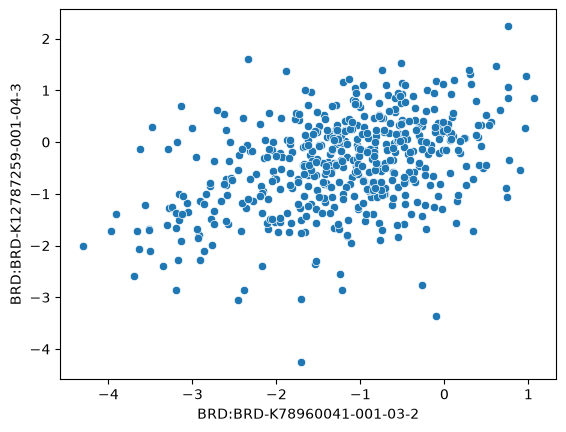

In [52]:
row = 50000

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)

           screen  dose repurposing_target                                                MOA                         IDs Drug.Name         Synonyms
4908  REP.PRIMARY   2.5        TP53, USP14  ANTITUMOR AGENT, UBIQUITIN C-TERMINAL HYDROLAS...  BRD:BRD-K26122255-001-01-7    VLX600  VLX-600, VLX600
4994  REP.PRIMARY   2.5              HIF1A                 HYPOXIA INDUCIBLE FACTOR ACTIVATOR  BRD:BRD-K44432556-001-05-5     ML228    ML-228, ML228
                                Drug                     Partner   Pearson
21820344  BRD:BRD-K44432556-001-05-5  BRD:BRD-K26122255-001-01-7  0.892588


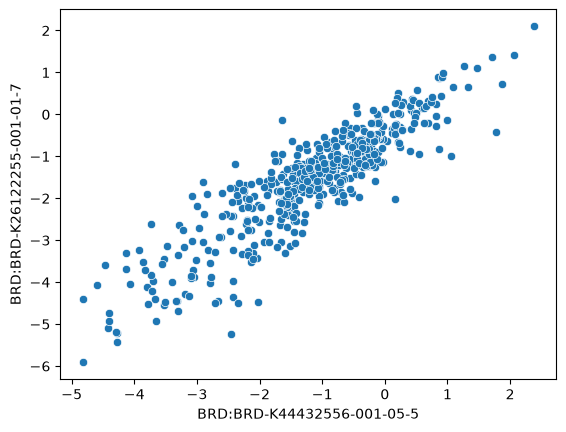

In [ ]:
#got a bit smarter about setting the row (but not much...)

row = 8

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)

This is a really neat example: while these drugs would appear to have to different annotated targets, a closer look reveals that they both act via similar mechanisms (both are iron chelators, meaning that they sponge up iron inside the cell, which is important for mitochondrial metabolism among other things). So, even though VLX600 is annotated as a 'antitumor agent, UPS inhibitor' and ML228 is annotated as a 'HIF activator', these are both just iron chelators with likely overlapping functions inside of cells (evidenced by their clear functional correlation!)

           screen  dose repurposing_target            MOA                         IDs Drug.Name Synonyms
1692  REP.PRIMARY   2.5             MAP2K1  MEK INHIBITOR  BRD:BRD-K26667523-001-02-5   TAK-733  TAK-733
2047  REP.PRIMARY   2.5             MAP3K1  MEK INHIBITOR  BRD:BRD-K37687095-001-06-9   AZD8330  AZD8330
                                Drug                     Partner   Pearson
22044104  BRD:BRD-K37687095-001-06-9  BRD:BRD-K26667523-001-02-5  0.867977


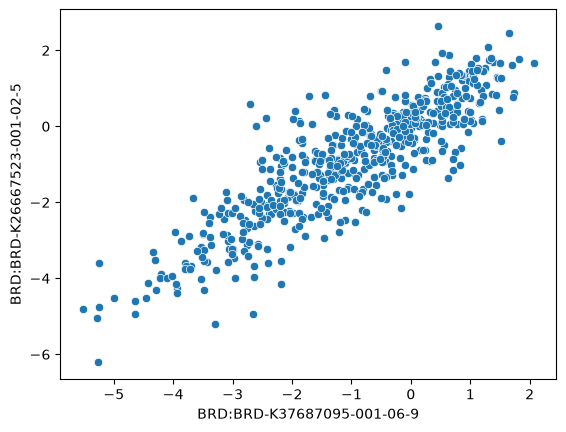

In [63]:
row = 31

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)